In [1]:
import pandas as pd
import datetime
import os
import timeit
from ortools.linear_solver import pywraplp
import numpy as np
import matplotlib.pyplot as plt # Import matplotlib for plotting

# --- 0. Setup ---
# Ensure the output directory exists
output_folder = "output"
if not os.path.isdir(output_folder):
    os.makedirs(output_folder)

# Define file paths
SMARD_DATA_FILE = 'data/SMARD_data.csv'
BESS_DATA_EXCEL_FILE = 'data/BESS_Data.xlsx' # Battery and Grid sheets
EV_DATA_FILE = 'data/EV.xlsx' # EV data file (for static EV parameters)


# --- 1. Data Definition and Loading into DataFrames ---

# Load SMARD data 
try:
    marketDF = pd.read_csv(SMARD_DATA_FILE, sep='\t')
    marketDF.columns = ["time", "market_price_1", "load", "wind", "solar"]
    marketDF['time'] = pd.to_datetime(marketDF['time'])

    
    marketDF = marketDF.iloc[:,:5] # Keep only relevant columns
    marketDF = marketDF[~pd.isnull(marketDF["time"])].fillna(0) # Handle potential NaNs
    marketDF.sort_values(by=["time"], inplace=True)

    timeInterval = marketDF.iloc[1]["time"] - marketDF.iloc[0]["time"]
    dt = round(timeInterval.total_seconds()) / (60 * 60) # in hours, should be 0.25 for 15 min data

    # Use a copy for marketDF to avoid SettingWithCopyWarning later, as in your notebook
    market1DF = marketDF.copy()

    # Create time_string with specific format for keys, matching your notebook's format: "%d/%m/%Y %H:%M"
    market1DF["time_string"] = market1DF["time"].apply(lambda x: (x + datetime.timedelta(seconds=0.002)).strftime("%d/%m/%Y %H:%M"))
    market1DF.set_index("time_string", inplace=True)
    marketDF = market1DF # Overwrite marketDF with the indexed version

except FileNotFoundError:
    print(f"Error: {SMARD_DATA_FILE} not found. Please ensure it's in the correct directory.")
    exit()
except Exception as e:
    print(f"Error processing {SMARD_DATA_FILE}: {e}")
    exit()


# Load BESS and Grid data from Excel file (as in BESS_op.ipynb)
try:
    workbook = pd.ExcelFile(BESS_DATA_EXCEL_FILE)

    gridDF = workbook.parse("Grid")
    gridDF = gridDF.iloc[:,:4]
    gridDF.columns = ["max_buy_power", "max_sell_power", "max_import_power", "max_export_power"]

    battDF = workbook.parse("Battery")
    battDF = battDF.iloc[:,:8]
    battDF.columns = ["max_charge_rate", "max_discharge_rate", "capacity", "charge_eff", "discharge_eff", "min_soc", "max_soc", "initial_soc"]

except FileNotFoundError:
    print(f"Error: {BESS_DATA_EXCEL_FILE} not found. Please ensure it's in the correct directory.")
    exit()
except Exception as e:
    print(f"Error processing {BESS_DATA_EXCEL_FILE}: {e}")
    exit()

# Convert dataframes to dictionary structure as in your notebook
marketDict = marketDF.to_dict(orient='dict')
gridDict = {col: gridDF[col].iloc[0] for col in gridDF.columns} # Assuming single row
battDict = {col: battDF[col].iloc[0] for col in battDF.columns} # Assuming single row

# --- Load EV static data ---
ev_ids = [] # Initialize ev_ids
try:
    workbook = pd.ExcelFile(EV_DATA_FILE)
    ev_raw_df=workbook.parse("EV_Data")
    ev_parameters = {}
    for _, row in ev_raw_df.iterrows():
        ev_id = row['CarID']
        ev_parameters[ev_id] = {
            'capacity_kwh': float(row['Capacity_kWh']),
            'initial_soe': float(row['Initial_SoC']) / 100,
            'min_soe': float(row['Min_SoC']) / 100,
            'max_soe': float(row['Max_SoC']) / 100,
            'max_power_kw': float(row['MaxPower_kW']),
            'charge_efficiency': float(row['Charge_Efficiency']),
            'discharge_efficiency': float(row['Discharge_Efficiency']),
            'desired_final_soe': float(row['Desired_Final_SoC']) / 100
        }
    num_evs = len(ev_parameters)
    ev_ids = list(ev_parameters.keys())

except FileNotFoundError:
    print(f"Error: {EV_DATA_FILE} not found. Please ensure it's in the correct directory.")
    num_evs = 0; ev_parameters = {}; ev_ids = []
except KeyError as e:
    print(f"Error reading {EV_DATA_FILE}: Missing expected column - {e}. Please check CSV headers.")
    num_evs = 0; ev_parameters = {}; ev_ids = []
except Exception as e:
    print(f"Error processing {EV_DATA_FILE}: {e}")
    num_evs = 0; ev_parameters = {}; ev_ids = []

# --- Load EV Connection Data ---
ev_connection_data = {} # Initialize empty dict
if num_evs > 0: # Only attempt to load if we successfully identified EVs from EV_DATA_FILE
    try:
        ev_conn_df = ev_raw_df=workbook.parse("Docking_Time")
        ev_conn_df.columns = ["Time", "EV001", "EV002", "EV003"]
        ev_conn_df['Time'] = pd.to_datetime(ev_conn_df['Time'], format="%Y-%m-%d %H:%M") # Adjust format if needed
        ev_conn_df.set_index('Time', inplace=True)

        # Check if column names for EVs match ev_ids from static data
        missing_conn_cols = [f'{ev_id}_docking' for ev_id in ev_ids if f'{ev_id}' not in ev_conn_df.columns]
        if missing_conn_cols:
            print(f"Warning: Missing docking columns for EVs in {EV_DATA_FILE}: {missing_conn_cols}")
            print("These EVs will be treated as never connected.")
 
        # Convert to dictionary of dictionaries for easy lookup: {EV_ID: {DateTime_str: docking_status}}
        for ev_id in ev_ids:
            # Check if the column exists in ev_conn_df, if not, treat as always disconnected
            if ev_id in ev_conn_df.columns:
                ev_connection_data[ev_id] = ev_conn_df[ev_id].to_dict()
                # Ensure keys are in the same format as time_steps_str
                ev_connection_data[ev_id] = {k.strftime("%d/%m/%Y %H:%M"): v for k,v in ev_connection_data[ev_id].items()}
            else:
                ev_connection_data[ev_id] = {t_str: 0 for t_str in marketDF.index} # Default to disconnected
        print(f"EV connection data loaded from '{EV_DATA_FILE}'.")
    except FileNotFoundError:
        print(f"Error: {EV_DATA_FILE} not found. EVs will be treated as never connected.")
    except Exception as e:
        print(f"Error processing {EV_DATA_FILE}: {e}. EVs will be treated as never connected.")


# --- 2. Consolidate into a single 'input' object (matching your notebook's structure) ---
input = type("input", (dict,), {})()
input.update({
    "simData": {
        "startTime": datetime.datetime.strptime(marketDF.index[0], "%d/%m/%Y %H:%M"),
        "dt": dt,
        "tIndex": marketDF.shape[0]
        },
    "market": {
        key: {
            sub_key: sub_item for sub_key, sub_item in marketDict[key].items()
            } for key in marketDict.keys() if key != "time"
        },
    "grid": {
        key: item for key, item in gridDict.items()
        },
    "batt": {
        key: item for key, item in battDict.items()
        },
    "evs": { # Add EV static data to the input object
        ev_id: ev_params for ev_id, ev_params in ev_parameters.items()
        },
    "ev_conn_status": { # NEW: Add EV connection status data
        ev_id: conn_status_dict for ev_id, conn_status_dict in ev_connection_data.items()
        }
    })


EV connection data loaded from 'data/EV.xlsx'.


--- Consolidated Input Data Structure ---
Simulation Data: {'startTime': datetime.datetime(2024, 10, 25, 1, 0), 'dt': 0.25, 'tIndex': 96}
Market Data (first 3 entries for market_price_1):
Market_price_1: {'25/10/2024 01:00': 82.07, '25/10/2024 01:15': 82.07, '25/10/2024 01:30': 82.07}...
Grid Data: {'max_buy_power': np.int64(99999), 'max_sell_power': np.int64(99999), 'max_import_power': np.int64(99999), 'max_export_power': np.int64(99999)}
Battery Data: {'max_charge_rate': np.int64(2000), 'max_discharge_rate': np.int64(2000), 'capacity': np.int64(4000), 'charge_eff': np.float64(0.05), 'discharge_eff': np.float64(0.05), 'min_soc': np.float64(0.1), 'max_soc': np.float64(0.95), 'initial_soc': np.float64(0.5)}
EV Static Data:
  EV001: {'capacity_kwh': 200.0, 'initial_soe': 0.2, 'min_soe': 0.1, 'max_soe': 0.9, 'max_power_kw': 50.0, 'charge_efficiency': 0.95, 'discharge_efficiency': 0.95, 'desired_final_soe': 0.9}
  EV002: {'capacity_kwh': 200.0, 'initial_soe': 0.4, 'min_soe': 0.1, 'max_soe'

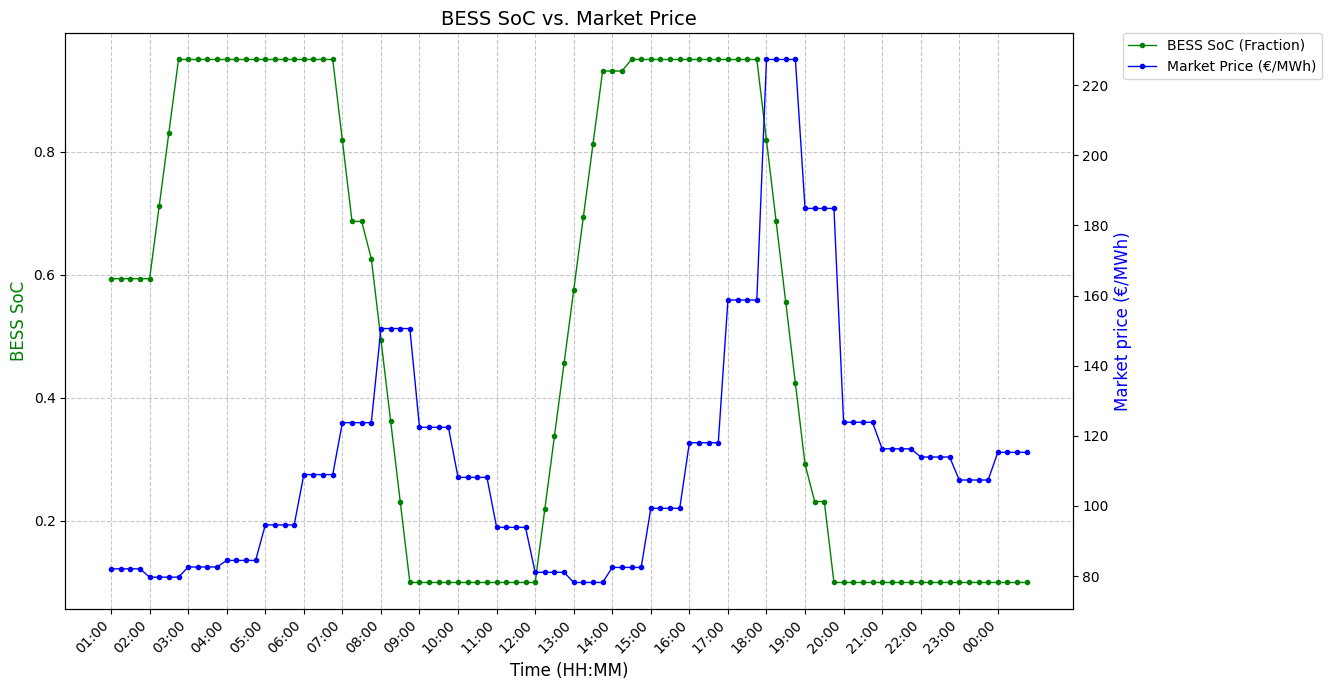

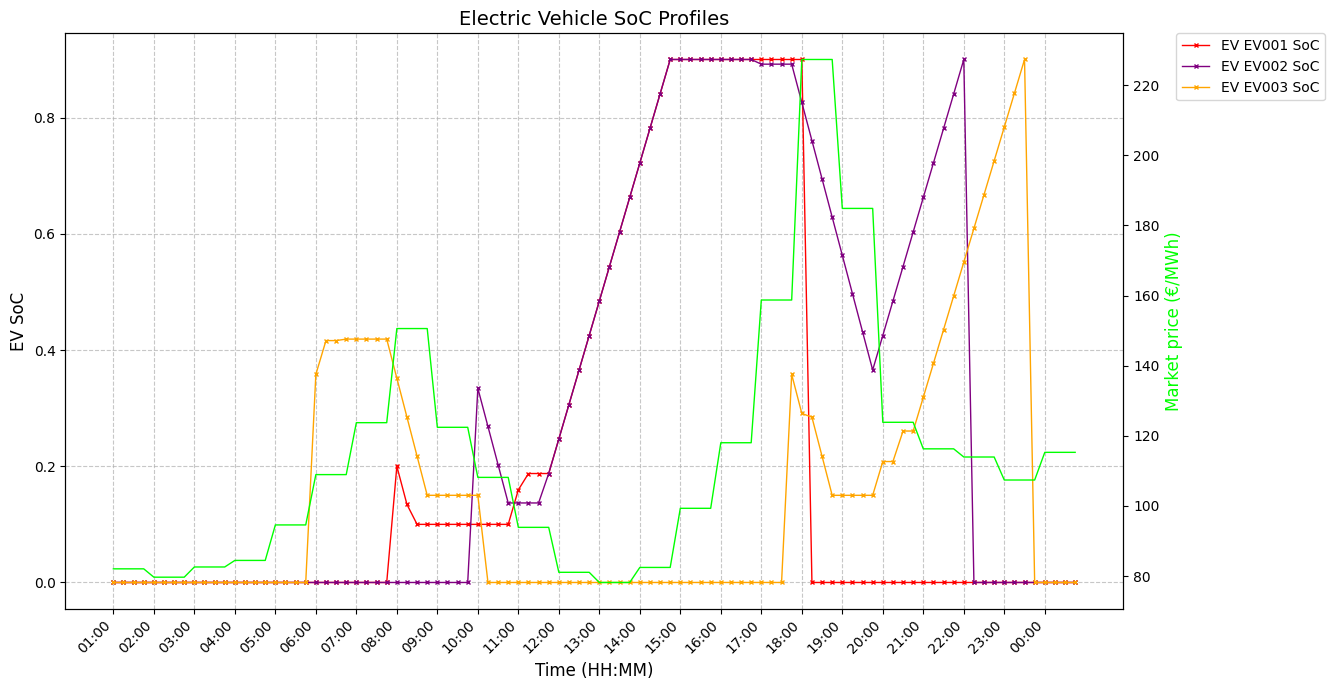

In [2]:
# --- 2. Consolidate into a single 'input' object ---
input = type("input", (dict,), {})()
input.update({
    "simData": {
        "startTime": datetime.datetime.strptime(marketDF.index[0], "%d/%m/%Y %H:%M"),
        "dt": dt,
        "tIndex": marketDF.shape[0]
        },
    "market": {
        key: {
            sub_key: sub_item for sub_key, sub_item in marketDict[key].items()
            } for key in marketDict.keys() if key != "time"
        },
    "grid": {
        key: item for key, item in gridDict.items()
        },
    "batt": {
        key: item for key, item in battDict.items()
        },
    "evs": { # Add EV static data to the input object
        ev_id: ev_params for ev_id, ev_params in ev_parameters.items()
        },
    "ev_conn_status": { # NEW: Add EV connection status data
        ev_id: conn_status_dict for ev_id, conn_status_dict in ev_connection_data.items()
        }
    })

# --- Display the consolidated input structure ---
print("--- Consolidated Input Data Structure ---")
print(f"Simulation Data: {input['simData']}")
print(f"Market Data (first 3 entries for market_price_1):")
print(f"Market_price_1: {dict(list(input['market']['market_price_1'].items())[:3])}...")
print(f"Grid Data: {input['grid']}")
print(f"Battery Data: {input['batt']}")
if num_evs > 0: # Only print EV data if EVs are loaded
    print(f"EV Static Data:")
    for ev_id, params in input['evs'].items():
        print(f"  {ev_id}: {params}")
    print(f"EV Connection Data (first entry per EV):")
    for ev_id, conn_data in input['ev_conn_status'].items():
        if conn_data: # Ensure there's data to show
            first_entry = next(iter(conn_data.items()))
            print(f"  {ev_id}: {first_entry}...")
        else:
            print(f"  {ev_id}: No connection data loaded (EV likely disconnected).")


# --- 3. Optimization Model Definition ---

solver = pywraplp.Solver.CreateSolver('SCIP')
if not solver:
    raise Exception('Could not create solver')

inf = solver.infinity()

tIndex = input["simData"]["tIndex"]
dt = input["simData"]["dt"]

# Create datetime string array for time steps keys 
startTime = input["simData"]["startTime"].strftime("%d/%m/%Y %H:%M")
timestamp = pd.date_range(startTime, periods=tIndex, freq=str(int(dt * 60)) + "min")
time_steps_str = [timestamp[i].strftime("%d/%m/%Y %H:%M") for i in range(len(timestamp))]


# --- 4. Define Decision Variables ---
time_s = timeit.default_timer()

# Grid power flow (positive for import, negative for export, as per your notebook's vGrid usage)
vGrid = {t: solver.NumVar(-inf, inf, f'vGrid_{t}') for t in time_steps_str}

# Battery power flow (vBattPower = vCharge + vDischarge)
# vCharge is negative when charging, vDischarge is positive when discharging
vBattPower = {t: solver.NumVar(-inf, inf, f'vBattPower_{t}') for t in time_steps_str}
vCharge = {t: solver.NumVar(-inf, 0, f'vCharge_{t}') for t in time_steps_str} # Negative for charging
vDischarge = {t: solver.NumVar(0, inf, f'vDischarge_{t}') for t in time_steps_str} # Positive for discharging

# Binary variable for charge status (1 if charging, 0 if discharging/idle)
vChargeStatus = {t: solver.BoolVar(f'vChargeStatus_{t}') for t in time_steps_str}

# State of Charge (SOC) in range [min_soc, max_soc] 
vSOC = {t: solver.NumVar(float(input["batt"]["min_soc"]), float(input["batt"]["max_soc"]), f'vSOC_{t}') for t in time_steps_str}

# EV variables (only define if EVs are loaded)
if num_evs > 0:
    ev_charge = {ev_id: {t: solver.NumVar(0, float(input['evs'][ev_id]['max_power_kw']), f'ev_{ev_id}_charge_{t}') for t in time_steps_str} for ev_id in ev_ids}
    ev_discharge = {ev_id: {t: solver.NumVar(0, float(input['evs'][ev_id]['max_power_kw']), f'ev_{ev_id}_discharge_{t}') for t in time_steps_str} for ev_id in ev_ids}
    # MODIFIED: EV SOE bounds are now globally 0 to full capacity. Min/Max SOE limits are applied conditionally when docked.
    ev_soe = {ev_id: {t: solver.NumVar(0, float(input['evs'][ev_id]['capacity_kwh']), f'ev_{ev_id}_soe_{t}') for t in time_steps_str} for ev_id in ev_ids}
    ev_is_charging = {ev_id: {t: solver.BoolVar(f'ev_{ev_id}_is_charging_{t}') for t in time_steps_str} for ev_id in ev_ids}
    ev_is_discharging = {ev_id: {t: solver.BoolVar(f'ev_{ev_id}_is_discharging_{t}') for t in time_steps_str} for ev_id in ev_ids}
    # ev_connected is now a parameter. It's read from input['ev_conn_status']


# --- 5. Define Constraints (Updated for EVs and Power Balance) ---
M = 1000000 

for i, t_str in enumerate(time_steps_str):
    # Power balance contribution from EVs
    total_ev_power_contribution = 0
    if num_evs > 0:
        total_ev_power_contribution = solver.Sum([ev_discharge[ev_id][t_str] - ev_charge[ev_id][t_str] for ev_id in ev_ids])


    # Grid constraints (Eqn. 1, 2, 3 in your notebook)
    # Eqn. 1: Power Balance: Load - Renewables - Battery Power - Total EV Power = Grid Power Flow
    solver.Add(vGrid[t_str] == input["market"]["load"][t_str] - input["market"]["solar"][t_str] - input["market"]["wind"][t_str] - vBattPower[t_str] - total_ev_power_contribution)

    # Eqn. 2: Grid import/export limits for vGrid (MW, based on original units)
    solver.Add(vGrid[t_str] <= float(input["grid"]["max_buy_power"]))
    solver.Add(vGrid[t_str] >= -float(input["grid"]["max_sell_power"]))

    # Eqn. 3: Grid import/export limits for combined demand/supply (MW, based on original units)
    solver.Add(input["market"]["load"][t_str] - input["market"]["solar"][t_str] - input["market"]["wind"][t_str] + vDischarge[t_str] + vCharge[t_str] + total_ev_power_contribution <= float(input["grid"]["max_import_power"]))
    solver.Add(input["market"]["load"][t_str] - input["market"]["solar"][t_str] - input["market"]["wind"][t_str] + vDischarge[t_str] + vCharge[t_str] + total_ev_power_contribution >= -float(input["grid"]["max_export_power"]))


    # Battery constraints (Eqn. 4, 5, 6, 7 in your notebook)
    # Eqn. 4: Battery power relationship
    solver.Add(vBattPower[t_str] == vCharge[t_str] + vDischarge[t_str])

    # Eqn. 5(a) & 5(b): Prevent simultaneous charge/discharge and apply rates using binary variable
    solver.Add(vCharge[t_str] >= -float(input["batt"]["max_charge_rate"]) * vChargeStatus[t_str])
    solver.Add(vCharge[t_str] <= 0) # Ensures vCharge is always non-positive when not charging

    solver.Add(vDischarge[t_str] <= float(input["batt"]["max_discharge_rate"]) * (1 - vChargeStatus[t_str]))
    solver.Add(vDischarge[t_str] >= 0) # Ensures vDischarge is always non-negative when not discharging

    # Eqn. 6: SOC Update 
    if i == 0:
        solver.Add(vSOC[t_str] == float(input["batt"]["initial_soc"]) - (dt / float(input["batt"]["capacity"])) * \
                   (vCharge[t_str] * (1 - float(input["batt"]["charge_eff"])) + vDischarge[t_str] / (1 - float(input["batt"]["discharge_eff"]))))
    else:
        prev_t_str = time_steps_str[i-1]
        solver.Add(vSOC[t_str] == vSOC[prev_t_str] - (dt / float(input["batt"]["capacity"])) * \
                   (vCharge[t_str] * (1 - float(input["batt"]["charge_eff"])) + vDischarge[t_str] / (1 - float(input["batt"]["discharge_eff"]))))

    # Eqn. 7: SOC limits 
    solver.Add(vSOC[t_str] >= float(input["batt"]["min_soc"]))
    solver.Add(vSOC[t_str] <= float(input["batt"]["max_soc"]))

    # --- EV Constraints ---
    if num_evs > 0:
        for ev_id in ev_ids:
            ev_params = input['evs'][ev_id]
            ev_is_docked = input['ev_conn_status'][ev_id][t_str] # Get docking status for this EV at this time

            # If not docked, ensure power exchange is zero.
            if ev_is_docked == 0:
                solver.Add(ev_charge[ev_id][t_str] == 0)
                solver.Add(ev_discharge[ev_id][t_str] == 0)
                # When not docked, SOE simply holds its value based on the SOE update equation
                # and 0 charge/discharge. No explicit SOE constraint here.
            else: # If EV is docked (ev_is_docked == 1)
                # Link charge/discharge to binary variables via Big M (if needed, already in variable def)
                solver.Add(ev_charge[ev_id][t_str] <= M) # Max power from variable definition
                solver.Add(ev_discharge[ev_id][t_str] <= M) # Max power from variable definition

                # EV Energy Balance 
                current_ev_capacity = float(ev_params['capacity_kwh'])
                initial_soe_kwh_from_data = float(ev_params['initial_soe']) * current_ev_capacity
                charge_eff = float(ev_params['charge_efficiency'])
                discharge_eff = float(ev_params['discharge_efficiency'])

                # Determine if this is the very first time step this EV is docked in the simulation
                is_first_dock_at_this_time_step = False
                if i == 0 and ev_is_docked == 1:
                    is_first_dock_at_this_time_step = True
                elif i > 0 and ev_is_docked == 1 and input['ev_conn_status'][ev_id][time_steps_str[i-1]] == 0:
                    is_first_dock_at_this_time_step = True

                if is_first_dock_at_this_time_step:
                    # If this is the first time the EV is docked, start its SOE from its initial_soe from data
                    solver.Add(ev_soe[ev_id][t_str] == initial_soe_kwh_from_data +
                               ev_charge[ev_id][t_str] * charge_eff * dt -
                               ev_discharge[ev_id][t_str] / discharge_eff * dt)
                else:
                    # Otherwise (if already docked from previous step or not first connection),
                    # continue the SOE calculation from the previous time step's SOE variable
                    prev_t_str = time_steps_str[i-1]
                    solver.Add(ev_soe[ev_id][t_str] == ev_soe[ev_id][prev_t_str] +
                               ev_charge[ev_id][t_str] * charge_eff * dt -
                               ev_discharge[ev_id][t_str] / discharge_eff * dt)

                # Prevent simultaneous EV charge/discharge
                solver.Add(ev_charge[ev_id][t_str] <= ev_is_charging[ev_id][t_str] * M)
                solver.Add(ev_discharge[ev_id][t_str] <= ev_is_discharging[ev_id][t_str] * M)
                solver.Add(ev_is_charging[ev_id][t_str] + ev_is_discharging[ev_id][t_str] <= 1)
                
                # EV SOE limits (applied ONLY when docked)
                solver.Add(ev_soe[ev_id][t_str] >= float(ev_params['min_soe']) * current_ev_capacity)
                solver.Add(ev_soe[ev_id][t_str] <= float(ev_params['max_soe']) * current_ev_capacity)


# --- Final SOE at Departure Constraint (Outside the main time loop) ---
if num_evs > 0:
    for ev_id in ev_ids:
        ev_params = input['evs'][ev_id]
        
        # Find the LAST time step where the EV is docked for the final SOE constraint
        last_docked_time_str = None
        for t_idx_rev in range(tIndex - 1, -1, -1): # Iterate backwards from end of simulation
            t_str_rev = time_steps_str[t_idx_rev]
            # Check if EV is docked at this time step
            if input['ev_conn_status'][ev_id][t_str_rev] == 1:
                last_docked_time_str = t_str_rev
                break # Found the last docked time, break loop

        if last_docked_time_str:
            solver.Add(ev_soe[ev_id][last_docked_time_str] >= float(ev_params['desired_final_soe']) * float(ev_params['capacity_kwh']))
            print(f"Applied final SOE constraint for EV {ev_id} at its last docked time: {last_docked_time_str}")
        else:
            # If EV is never docked (last_docked_time_str remains None), then the desired final SOE constraint is ignored.
            print(f"Info: Final SOE constraint for EV {ev_id} (desired {ev_params['desired_final_soe'] * 100:.1f}%) was NOT applied. "
                  f"This EV appears to be never docked during the simulation period according to '{EV_DATA_FILE}'. This is expected behavior if the EV is truly never connected.")

# --- 6. Define Objective Function ---
obj = solver.Sum([vGrid[t_str] * input["market"]["market_price_1"][t_str] * dt for t_str in time_steps_str])
solver.Minimize(obj)

# --- 7. Solve the problem ---
status = solver.Solve()

# --- 8. Print Results and Export ---
time_e = timeit.default_timer()
runTime = round(time_e - time_s, 4)

if status == solver.OPTIMAL or status == solver.FEASIBLE:
    print("Solution is found.")
    print("Number of variables =", solver.NumVariables())
    print("Number of constraints =", solver.NumConstraints())
    print("Computation time = ", runTime)

    # Extract solution values and prepare for Excel export
    excelWriter = pd.ExcelWriter(os.path.join(output_folder, 'Result_BESS_V2G.xlsx'), engine='xlsxwriter')

    objValue = round(solver.Objective().Value(), 2)

    objValueDF = pd.DataFrame.from_dict({"obj_value": objValue}, orient="index", columns=["Total Cost of Power (€)"])

    results_data = {
        "DateTime": time_steps_str,
        "Grid Power Flow (kW)": [vGrid[t].solution_value() for t in time_steps_str],
        "Battery Output (kW)": [vBattPower[t].solution_value() for t in time_steps_str],
        "Charging Power (kW)": [vCharge[t].solution_value() for t in time_steps_str],
        "Discharging Power (kW)": [vDischarge[t].solution_value() for t in time_steps_str],
        "State-of-charge (SOC)": [vSOC[t].solution_value() for t in time_steps_str],
        "Charge Status": [vChargeStatus[t].solution_value() for t in time_steps_str]
    }

    # Add EV results to the results_data if EVs are loaded
    if num_evs > 0:
        for ev_id in ev_ids:
            results_data[f"EV_{ev_id}_Charge (kW)"] = [ev_charge[ev_id][t].solution_value() for t in time_steps_str]
            results_data[f"EV_{ev_id}_Discharge (kW)"] = [ev_discharge[ev_id][t].solution_value() for t in time_steps_str]
            results_data[f"EV_{ev_id}_SOE (kWh)"] = [ev_soe[ev_id][t].solution_value() for t in time_steps_str]
            results_data[f"EV_{ev_id}_Docked"] = [input['ev_conn_status'][ev_id][t] for t in time_steps_str]

    Operation_df = pd.DataFrame(results_data)
    Operation_df.set_index('DateTime', inplace=True)

    # --- EV SOE (Fraction) columns  ---
    if num_evs > 0:
        for ev_id in ev_ids:
            ev_soe_column = f"EV_{ev_id}_SOE (kWh)"
            ev_capacity = input['evs'][ev_id]['capacity_kwh']
            # Only perform the division if ev_capacity is not zero to avoid division by zero errors
            if ev_capacity > 0:
                Operation_df[f"EV_{ev_id}_SOE (Fraction)"] = Operation_df[ev_soe_column] / ev_capacity
            else:
                Operation_df[f"EV_{ev_id}_SOE (Fraction)"] = 0.0 # Set to 0 if capacity is 0
                print(f"Warning: EV {ev_id} has 0 capacity, SOE fraction will be 0.")
    objValueDF.to_excel(excelWriter, sheet_name='Cost')
    Operation_df.to_excel(excelWriter, sheet_name='Operation')
    excelWriter.close()

    print(f"\nDetailed operation results saved to '{os.path.join(output_folder, 'Result_BESS_V2G.xlsx')}'")


    # --- Prepare x-axis labels for plotting (only hours and minutes) ---
    # Convert the DateTime index to datetime objects temporarily to format, then back to list of strings
    time_only_labels = [pd.to_datetime(ts, format="%d/%m/%Y %H:%M").strftime("%H:%M") for ts in Operation_df.index]
    
    # Define tick frequency for better readability (e.g., every 4th tick for 15-min data)
    tick_frequency = 4 # For 15-min data, this means showing labels every hour
    tick_locations = np.arange(0, len(time_only_labels), tick_frequency)
    tick_labels_to_show = [time_only_labels[i] for i in tick_locations]


    # --- Plotting Section 1: BESS SoC and Market Price ---
    fig1, ax1_1 = plt.subplots(figsize=(15, 7))

    ax1_1.grid(True, linestyle='--', alpha=0.7)
    # Set custom ticks and labels
    ax1_1.set_xticks(tick_locations)
    ax1_1.set_xticklabels(tick_labels_to_show, rotation=45, ha='right', fontsize=10)

    ax1_2 = ax1_1.twinx()

    ax1_1.plot(time_only_labels, Operation_df["State-of-charge (SOC)"], marker='o', linestyle='-', color='g', markersize=3, linewidth=1, label='BESS SoC (Fraction)')

    market_time_only_labels = [pd.to_datetime(ts, format="%d/%m/%Y %H:%M").strftime("%H:%M") for ts in marketDF.index]
    ax1_2.plot(market_time_only_labels, marketDF["market_price_1"], marker='o', linestyle='-', color='b', markersize=3, linewidth=1, label='Market Price (€/MWh)')


    ax1_1.set_xlabel('Time (HH:MM)', fontsize=12) # Adjusted label
    ax1_1.set_ylabel('BESS SoC', fontsize=12, color='g')
    ax1_2.set_ylabel('Market price (€/MWh)', fontsize=12, color='b')

    lines, labels = ax1_1.get_legend_handles_labels()
    lines2, labels2 = ax1_2.get_legend_handles_labels()
    ax1_2.legend(lines + lines2, labels + labels2, loc='upper left', bbox_to_anchor=(1.05, 1), borderaxespad=0.)

    plt.title('BESS SoC vs. Market Price', fontsize=14)
    plt.tight_layout(rect=[0, 0, 0.9, 1])
    plt.savefig(os.path.join(output_folder, 'BESS_SoC_and_Market_Price.png')) # Save BESS plot
    plt.show()

    # --- Plotting Section 2: EV State of Energy ---
    if num_evs > 0:
        fig2, ax2_1 = plt.subplots(figsize=(15, 7))
        ax2_1.grid(True, linestyle='--', alpha=0.7)
        # Set custom ticks and labels
        ax2_1.set_xticks(tick_locations)
        ax2_1.set_xticklabels(tick_labels_to_show, rotation=45, ha='right', fontsize=10)
        
        ax2_2 = ax2_1.twinx()

        ax2_1.set_xlabel('Time (HH:MM)', fontsize=12) # Adjusted label
        ax2_1.set_ylabel('EV SoC', fontsize=12)
        ax2_2.set_ylabel('Market price (€/MWh)', fontsize=12, color='lime')

        line_styles = ['--', ':', '-.', (0, (3, 1, 1, 1))]
        colors = ['r', 'purple', 'orange', 'cyan', 'magenta', 'brown', 'pink'] # More colors for more EVs
        
        for idx, ev_id in enumerate(ev_ids):
            ev_soe_column_fraction = f"EV_{ev_id}_SOE (Fraction)"
            if ev_soe_column_fraction in Operation_df.columns:
                ax2_1.plot(time_only_labels, Operation_df[ev_soe_column_fraction], # Use time_only_labels for x-axis
                         marker='x', linestyle='-', color=colors[idx % len(colors)],
                         markersize=3, linewidth=1, label=f'EV {ev_id} SoC')
            else:
                print(f"Warning: Column '{ev_soe_column_fraction}' not found in Operation_df. Skipping plot for EV {ev_id}.")

        ax2_2.plot(market_time_only_labels, marketDF["market_price_1"], linestyle='-', color='lime', markersize=3, linewidth=1, label='Market Price (€/MWh)')


        ax2_1.legend(loc='upper left', bbox_to_anchor=(1.05, 1), borderaxespad=0.)
        plt.title('Electric Vehicle SoC Profiles', fontsize=14)
        plt.tight_layout(rect=[0, 0, 0.9, 1])
        plt.savefig(os.path.join(output_folder, 'EV_SoC_Profiles.png'))
        plt.show()

        

elif status == pywraplp.Solver.INFEASIBLE:
    print('The problem is infeasible. Check your constraints and data.')
    print('Potential reasons for infeasibility include:')
    print('- BESS min/max SOC, capacity, and charge/discharge rates are too restrictive for the given load and market conditions.')
    print('- Grid import/export limits are too tight relative to the load and renewable generation.')
    print('- The overall power balance: Is grid import + BESS discharge + Renewables + EV discharge sufficient for load + BESS charge + Grid export + EV charge?')
    print('\nDebugging Tip: Review the data carefully and consider relaxing some constraints temporarily to identify the culprit.')
elif status == pywraplp.Solver.UNBOUNDED:
    print('The problem is unbounded. The objective can be improved indefinitely. This often indicates missing or incorrect constraints (e.g., no upper bound on grid import/export, or missing battery capacity limits).')
else:
    print(f'The problem could not be solved. Solver status: {status}')

